In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.utils import shuffle
from collections import Counter

In [2]:
iris = datasets.load_iris()

In [3]:
x, y = shuffle(iris.data, iris.target, random_state=13) # 打乱数据后的数据与标签

In [5]:
x = x.astype(np.float32)

In [8]:
offset = int(x.shape[0] * 0.7)

In [9]:
x_trin, y_train =x[:offset], y[:offset]

In [10]:
x_test, y_test = x[offset:], y[offset:]

In [12]:
y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

In [14]:
y_train.shape, y_test.shape, x_trin.shape, x_test.shape

((105, 1), (45, 1), (105, 4), (45, 4))

In [16]:
# 使用五折找最优k值
n_folds = 5
# 候选 k值
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]
x_train_folds = []
y_train_folds = []

In [17]:
x_train_folds = np.array_split(x_trin, n_folds)
y_train_folds = np.array_split(y_train, n_folds)

In [21]:
k_to_accuracies = {}

In [25]:
### 定义欧氏距离
def compute_distances(X, X_train):
    '''
    输入：
    X：测试样本实例矩阵
    X_train：训练样本实例矩阵
    输出：
    dists：欧式距离
    '''
    # 测试实例样本量
    num_test = X.shape[0]
    # 训练实例样本量
    num_train = X_train.shape[0]
    # 基于训练和测试维度的欧氏距离初始化
    dists = np.zeros((num_test, num_train))
    # 测试样本与训练样本的矩阵点乘
    M = np.dot(X, X_train.T)
    # 测试样本矩阵平方
    te = np.square(X).sum(axis=1)
    # 训练样本矩阵平方
    tr = np.square(X_train).sum(axis=1)
    # 计算欧式距离
    dists = np.sqrt(-2 * M + tr + np.matrix(te).T)
    return dists

In [ ]:
### 定义预测函数
def predict_labels(y_train, dists, k=1):
    '''
    输入：
    y_train：训练集标签
    dists：测试集与训练集之间的欧氏距离矩阵
    k：k值
    输出：
    y_pred：测试集预测结果
    '''
    # 测试样本量
    num_test = dists.shape[0]
    # 初始化测试集预测结果
    y_pred = np.zeros(num_test)
    # 遍历
    for i in range(num_test):
    # 初始化最近邻列表
        closest_y = []
        # 按欧氏距离矩阵排序后取索引，并用训练集标签按排序后的索引取值
        # 最后展平列表
        # 注意 np.argsort函数的用法
        labels = y_train[np.argsort(dists[i, :])].flatten()
        # 取最近的 k个值
        closest_y = labels[:k]
        # 对最近的 k个值进行计数统计
        # 这里注意 collections模块中的计数器 Counter的用法
        c = Counter(closest_y)
        # 取计数最多的那个类别
        y_pred[i] = c.most_common(1)[0][0]
    return y_pred

In [32]:
for k in k_choices:
    # 五折遍历
    for fold in range(n_folds):
        # 验证集
        validation_X_test = x_train_folds[fold]
        validation_y_test = y_train_folds[fold]
        temp_X_train = x_train_folds[:fold] + x_train_folds[fold+1:]
        temp_y_train = y_train_folds[:fold] + y_train_folds[fold+1:]
        # 计算距离
        temp_X_train = np.vstack(temp_X_train)
        temp_y_train = np.vstack(temp_y_train)
        # 预测
        temp_dists = compute_distances(validation_X_test, temp_X_train)
        temp_y_test_pred = predict_labels(temp_y_train,temp_dists, k=k)
        temp_y_test_pred = temp_y_test_pred.reshape((-1, 1))
        # 查看分类准确率
        num_correct = np.sum(temp_y_test_pred == validation_y_test)
        num_test = validation_X_test.shape[0]
        accuracy = float(num_correct) / num_test
        k_to_accuracies[k] = k_to_accuracies.get(k,[]) + [accuracy]
# 打印不同 k值、不同折数下的分类准确率
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.904762
k = 1, accuracy = 1.000000
k = 1, accuracy = 0.952381
k = 1, accuracy = 0.857143
k = 1, accuracy = 0.952381
k = 1, accuracy = 0.904762
k = 1, accuracy = 1.000000
k = 1, accuracy = 0.952381
k = 1, accuracy = 0.857143
k = 1, accuracy = 0.952381
k = 1, accuracy = 0.904762
k = 1, accuracy = 1.000000
k = 1, accuracy = 0.952381
k = 1, accuracy = 0.857143
k = 1, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 1.000000
k = 3, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 1.000000
k = 3, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 1.000000
k = 3, accuracy = 0.952381
k = 3, accuracy = 0.857143
k = 3, accuracy = 0.952381
k = 5, accuracy = 0.857143
k = 5, accuracy = 1.000000
k = 5, accuracy = 0.952381
k = 5, accuracy = 0.904762
k = 5, accuracy = 0.952381
k = 5, accuracy = 0.857143
k = 5, accuracy = 1.000000
k

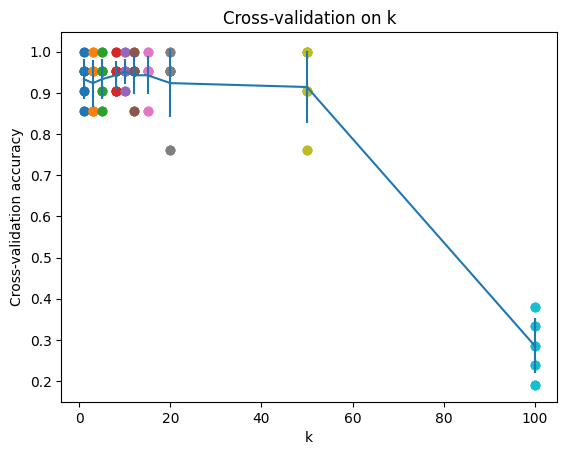

In [33]:
# 打印不同 k值、不同折数下的分类准确率
for k in k_choices:
# 取出第 k个 k值的分类准确率
    accuracies = k_to_accuracies[k]
    # 绘制不同 k值下分类准确率的散点图
    plt.scatter([k] * len(accuracies), accuracies)
    # 计算分类准确率均值并排序
    accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
# 计算分类准确率标准差并排序
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
# 绘制有置信区间的误差棒图
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
# 绘图标题
plt.title('Cross-validation on k')
# x轴标签
plt.xlabel('k')
# y轴标签
plt.ylabel('Cross-validation accuracy')
plt.show()